<a href="https://colab.research.google.com/github/Valrite/Digital-Image-Processing-Labs/blob/main/Lab4/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Prg 4. Demonstrate histogram equalization, contrast stretching and bit-plane slicing for a low contrast 2D image.

In [ ]:
# import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt


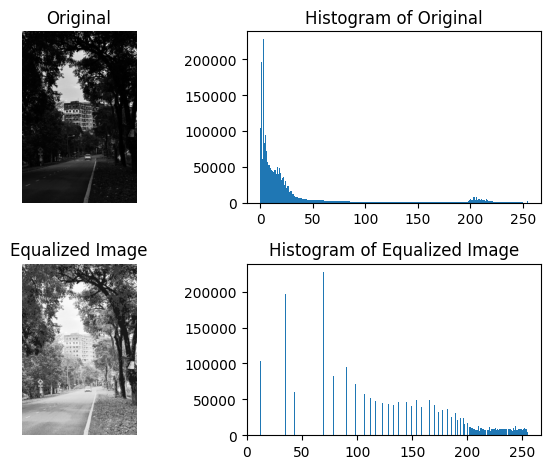

In [ ]:

# step 1: read image in grayscale mode
img  = cv2.imread("images/contrast.jpg",0)
L=256
nK = np.zeros(L)  #create an array of size 256 with all counts initialzed to 0

# step 2: compute histogram - update nK with the actual counts of pixel values
for pixel_val in img.flatten():
    nK[pixel_val]+= 1

N =  np.sum(nK)              # sum of all counts

#Step 3: Compute PDF. Divide each value in nK by count of pixels in image (N)
PDF = nK/N

# Step 4: Compute the cumulative distribution function CDF. Start from PDF of pixel 0.
#         Next value=probability of first 2 pixels. Next.. probability of first 3 pixels and so on.
CDF = np.zeros(L)
CDF[0]=  PDF[0]
for i in range(1,L):
    CDF[i] = CDF[i-1] + PDF[i]     # compute CDF as previous CDF + current PDF


# Step 5: Scale CDF. Multiply CDF with (L-1)
CDF = CDF * (L-1)

#Step 6: Round off CDF to find the new intensity value
new_pixels = np.round(CDF)

# Apply the new pixels on the image
equalized_img = new_pixels[img]

# Display original and equalized images along with their histograms
fig , ax = plt.subplots(2,2,)
ax[0,0].imshow(img,cmap="grey")
ax[0,0].set_title("Original")
ax[0,0].axis('off')
ax[0,1].hist(img.flatten(),bins=256)
ax[0,1].set_title("Histogram of Original")
ax[1,0].imshow(equalized_img,cmap="grey")
ax[1,0].set_title("Equalized Image")
ax[1,0].axis('off')
ax[1,1].hist(equalized_img.flatten(),bins=256)
ax[1,1].set_title("Histogram of Equalized Image")
plt.tight_layout()

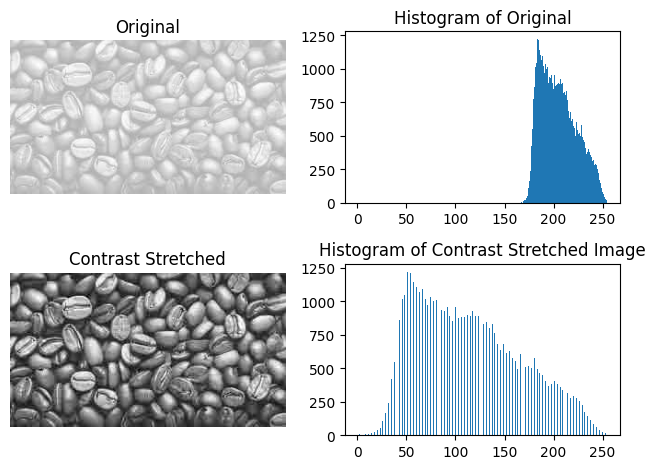

In [ ]:
# import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
# read image
I_old = cv2.imread("images/beans.jpeg",0)
# Compute I_min and I_max
I_min = np.min(I_old)
I_max = np.max(I_old)
I_new = ((I_old-I_min)/(I_max-I_min))*255                       # perform min-max normalization and scale to 0-255


# Display original and contrast-stretched images with their histograms
fig , ax = plt.subplots(2,2)
ax[0,0].imshow(I_old,cmap="grey",vmin=0,vmax=255)
ax[0,0].set_title("Original")
ax[0,0].axis('off')
ax[0,1].hist(I_old.flatten(),bins=256,range=(0,255))
ax[0,1].set_title("Histogram of Original")
ax[1,0].imshow(I_new,cmap="grey",vmin=0,vmax=255)
ax[1,0].set_title("Contrast Stretched")
ax[1,0].axis('off')
ax[1,1].hist(I_new.flatten(),bins=256,range=(0,255))
ax[1,1].set_title("Histogram of Contrast Stretched Image")
plt.tight_layout()

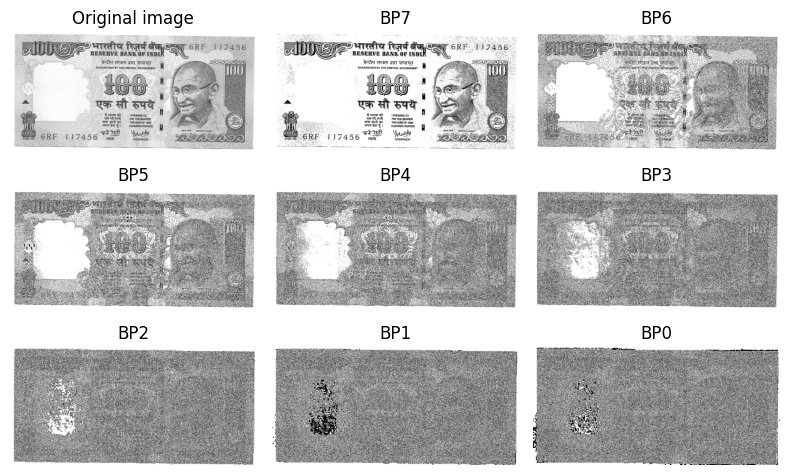

In [ ]:
img = cv2.imread('images/rupee.jpeg',0)

bp=[]
for i in range(8):
    bp.append(img & (1<<i))

fig,ax = plt.subplots (3,3, figsize=(8,5))

ax[0,0].imshow(img, cmap='gray')
ax[0,0].set_title('Original image')
ax[0,0].axis('off')

ind=1

for i in (range(1,3)):
    ax[0,i].imshow(bp[8-ind], cmap='gray')
    ax[0,i].set_title(f"BP{8-ind}")
    ax[0,i].axis('off')
    ind=ind+1

for i in (range(3)):
    ax[1,i].imshow(bp[8-ind], cmap='gray')
    ax[1,i].set_title(f"BP{8-ind}")
    ax[1,i].axis('off')
    ind=ind+1

for i in (range(3)):
    ax[2,i].imshow(bp[8-ind], cmap='gray')
    ax[2,i].set_title(f"BP{8-ind}")
    ax[2,i].axis('off')
    ind=ind+1
plt.tight_layout()
plt.show()

<h3>Histogram</h3>
<ul><li>A histogram of an image is a graphical representation of the distribution of pixel intensities in an image.
<li>It shows how many pixels in the image have each possible intensity value</li></ul>
<h3>Histogram Equalization</h3>

Histogram equalization is the process of balancing the intensity levels in the image. This technique works by redistributing pixel intensities so that the histogram of the output image is more spread out, covering the full range of possible intensity values. Given below is an example of a histogram equalized image



## Contrast Stretching
Low contrast images have a narrower range of pixel intensities. Contrast stretching works by spreading out the range of pixel intensities to enhance the differences between the dark and bright areas of the image. This improves visibility and makes details clearer.

###Steps in Contrast Stretching:

*   Find the lowest and highest intensity values in the image.
*   Map the original intensity values to a wider range, typically 0 to 255 for an 8-bit image, using the formula:


$$ I_{\text{new}} = \frac{I_{\text{old}} - I_{\min}}{I_{\max} - I_{\min}} \times 255 $$


*   Assign the new intensity values to pixels to produce the contrast-enhanced  image

<h3>Bit Plane Slicing</h3>
Bit plane slicing allows you to visualize the contribution of each bit of every pixel to the final image. To perform bit slicing you extract individual bit planes from an image by seperating specific bits in the binary representation of each pixel.

<h4>Steps</h4>
<ul>
<li> Each pixel is represented as a 8-bit binary number (ex: 11001101)
<li>Construct 8 separate images... each retaining only 1 value in the pixel. Ex: for a bit plane(8)  image, retain only the 8th bit of each pixel and set all other bits to 0. (ex: 11001101 ==> 10000000). This is done for every pixel in the image to obtain the 8th bit plane image.
<li> Same is repeated for construct the bit plane images of the remaining 7 bits in each pixel.
</ul>

To generate bit plane image for 6th bit of a pixel say (10101101), perform and operation of the pixel intensity with $2^6$ i.e. 64 or 00100000.

$$ B_6(x,y) = 10101101 \& 00100000 = 00100000 $$

In code, this is achieved by
```
bit_planes = [(image & (1<<i)) for i in range(8)]
# left shifting 1 by i positions helps to generate different powers of 2^i

```
